# Project: Multi-Modal Binary Change Detection


In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
base_path = '/content/drive/MyDrive/change_detection_assignment_data'
zip_files = ['train.zip', 'val.zip', 'test.zip']
extract_dir = '/content/drive/MyDrive/GalaxEye Space — Technical Assessment Submission/dataset'

os.makedirs(extract_dir, exist_ok=True)

for zf in zip_files:
    path_to_zip = os.path.join(base_path, zf)
    if os.path.exists(path_to_zip):
        print(f'\n Force Extracting {zf}...')
        # Changed -n to -o to FORCE OVERWRITE and fix broken/partial folders
        !unzip -q -o "{path_to_zip}" -d "{extract_dir}"
    else:
        print(f'Error: {zf} not found at {path_to_zip}')

print('\n=============================================')
print('🔍 INSTANT VERIFICATION (Direct from Colab Disk)')
print('=============================================')

# Instantly check if the folders exist and list their subfolders
for split in ['train', 'val', 'test']:
    split_path = os.path.join(extract_dir, split)
    if os.path.exists(split_path):
        contents = os.listdir(split_path)
        print(f"{split}/ folder successfully found! It contains: {contents}")
    else:
        print(f"{split}/ folder is STILL missing. Check inside {extract_dir} for double-nested folders.")

Mounted at /content/drive

 Force Extracting train.zip...

 Force Extracting val.zip...

 Force Extracting test.zip...

🔍 INSTANT VERIFICATION (Direct from Colab Disk)
train/ folder successfully found! It contains: ['post-event', 'pre-event', 'target']
val/ folder successfully found! It contains: ['post-event', 'pre-event', 'target']
test/ folder successfully found! It contains: ['post-event', 'pre-event', 'target']


In [2]:
import glob

# Explore dataset structure
def summarize_dir(path):
    files = glob.glob(os.path.join(path, '**/*'), recursive=True)
    images = [f for f in files if f.endswith(('.png', '.jpg', '.tif'))]
    print(f'Summary for {path}:')
    print(f' - Total files: {len(files)}')
    print(f' - Image files: {len(images)}')

summarize_dir(extract_dir)

Summary for /content/drive/MyDrive/GalaxEye Space — Technical Assessment Submission/dataset:
 - Total files: 9588
 - Image files: 9576


### Step 1: Install and Import Required Libraries

In [3]:
!pip install -q rasterio tifffile

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from tqdm.notebook import tqdm

# Define base paths
DATASET_DIR = '/content/drive/MyDrive/GalaxEye Space — Technical Assessment Submission/dataset'
SPLITS = ['train', 'val', 'test']

### Step 2: Class Distribution Analysis & Label Remapping

In [4]:
def remap_labels(mask):
    """
    Remaps labels based on the assignment rules:
    0 (Background) -> 0 (No-Change)
    1 (Intact)     -> 0 (No-Change)
    2 (Damaged)    -> 1 (Change)
    3 (Destroyed)  -> 1 (Change)
    """
    remapped = np.copy(mask)
    remapped[mask == 1] = 0
    remapped[mask == 2] = 1
    remapped[mask == 3] = 1
    return remapped

print("--- Class Distribution Analysis ---")
for split in SPLITS:
    target_dir = os.path.join(DATASET_DIR, split, 'target')
    mask_files = glob.glob(os.path.join(target_dir, '*.tif'))

    if not mask_files:
        print(f"No mask files found for split: {split}")
        continue

    total_pixels = 0
    change_pixels = 0

    for mf in tqdm(mask_files, desc=f"Processing {split} masks"):
        with rasterio.open(mf) as src:
            mask = src.read(1) # Read first band

        remapped_mask = remap_labels(mask)

        total_pixels += remapped_mask.size
        change_pixels += np.sum(remapped_mask == 1)

    no_change_pixels = total_pixels - change_pixels
    change_ratio = (change_pixels / total_pixels) * 100

    print(f"\nSplit: {split.upper()}")
    print(f"Total Pixels: {total_pixels:,}")
    print(f"No-Change Pixels (0): {no_change_pixels:,} ({100-change_ratio:.2f}%)")
    print(f"Change Pixels (1):    {change_pixels:,} ({change_ratio:.2f}%)")
    print(f"Ratio (Change : No-Change) -> 1 : {no_change_pixels/max(change_pixels, 1):.2f}")
    print("-" * 40)

--- Class Distribution Analysis ---


Processing train masks:   0%|          | 0/2781 [00:00<?, ?it/s]


Split: TRAIN
Total Pixels: 2,916,089,856
No-Change Pixels (0): 2,870,320,706 (98.43%)
Change Pixels (1):    45,769,150 (1.57%)
Ratio (Change : No-Change) -> 1 : 62.71
----------------------------------------


Processing val masks:   0%|          | 0/334 [00:00<?, ?it/s]


Split: VAL
Total Pixels: 350,224,384
No-Change Pixels (0): 342,518,211 (97.80%)
Change Pixels (1):    7,706,173 (2.20%)
Ratio (Change : No-Change) -> 1 : 44.45
----------------------------------------


Processing test masks:   0%|          | 0/77 [00:00<?, ?it/s]


Split: TEST
Total Pixels: 80,740,352
No-Change Pixels (0): 80,131,158 (99.25%)
Change Pixels (1):    609,194 (0.75%)
Ratio (Change : No-Change) -> 1 : 131.54
----------------------------------------


### Step 3: Modality Inspection and Co-registration Check


--- Processing Sample ---
Pre-event (EO):   scene_01_000001_building_damage.tif
Post-event (SAR): scene_01_000001_building_damage.tif
Target Mask:      scene_01_000001_building_damage.tif

--- Co-registration Check ---
Pre-event shape:  (1024, 1024), Bands: 3, Bounds: BoundingBox(left=9.796201318793191, bottom=1.8418289899905278, right=9.800883481724254, top=1.846511153)
Post-event shape: (1024, 1024), Bands: 1, Bounds: BoundingBox(left=9.796201318793191, bottom=1.8418289899905278, right=9.800883481724254, top=1.846511153)
Target shape:     (1024, 1024), Bands: 1, Bounds: BoundingBox(left=9.796201318793191, bottom=1.8418289899905278, right=9.800883481724254, top=1.846511153)
Verification: Spatial extents match perfectly.

--- Value Ranges ---
Pre-Event EO (min/max):   0 / 218
Post-Event SAR (min/max): 0.00 / 238.00


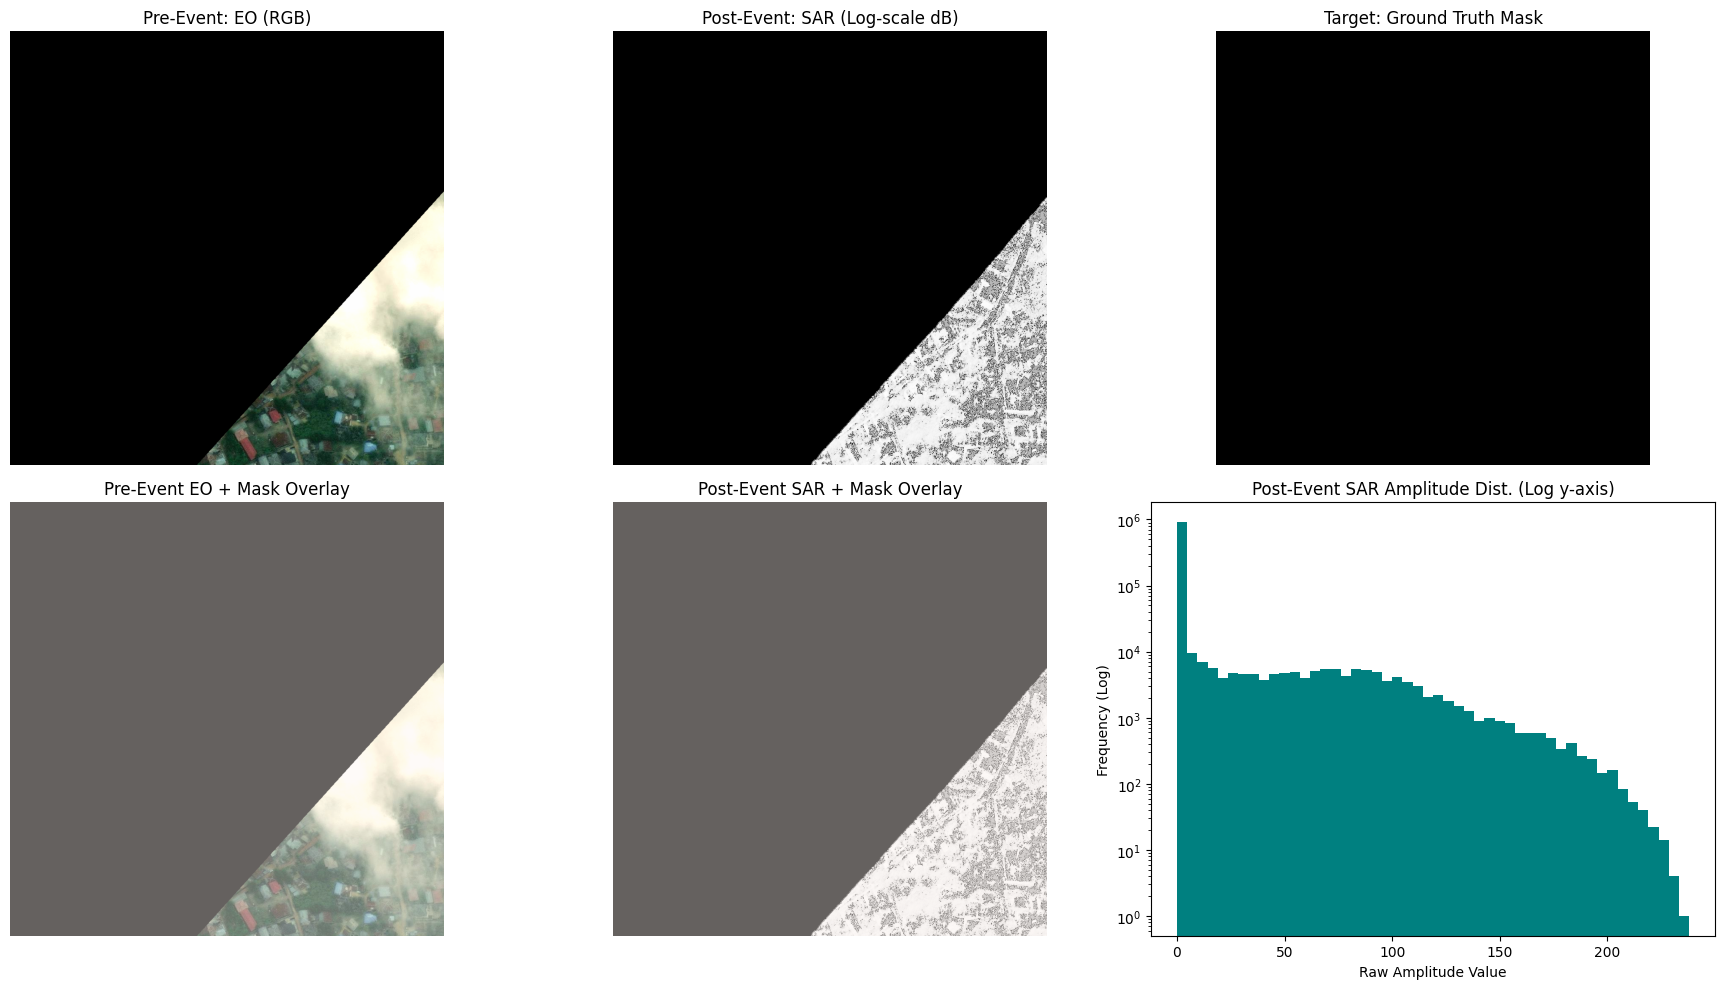

In [5]:
def normalize_eo(img_array):
    """Normalize EO image for 8-bit display."""
    img_array = img_array.astype(np.float32)
    p2, p98 = np.percentile(img_array, (2, 98))
    img_array = np.clip(img_array, p2, p98)
    return (img_array - p2) / (p98 - p2 + 1e-8)

def process_sar(sar_array):
    """Convert SAR amplitude to Log-scale (dB) for better visualization."""
    sar_array = sar_array.astype(np.float32)
    sar_db = 10 * np.log10(sar_array + 1e-6)
    return sar_db

def remap_labels(mask):
    remapped = np.copy(mask)
    remapped[mask == 1] = 0
    remapped[mask == 2] = 1
    remapped[mask == 3] = 1
    return remapped

sample_split = 'train'
pre_dir = os.path.join(DATASET_DIR, sample_split, 'pre-event')
post_dir = os.path.join(DATASET_DIR, sample_split, 'post-event')
target_dir = os.path.join(DATASET_DIR, sample_split, 'target')

# Dynamically list files
pre_files = sorted([f for f in os.listdir(pre_dir) if f.endswith('.tif')])
post_files = sorted([f for f in os.listdir(post_dir) if f.endswith('.tif')])
target_files = sorted([f for f in os.listdir(target_dir) if f.endswith('.tif')])

if not target_files:
    print(f"Error: No .tif files found in {target_dir}!")
else:
    pre_path = os.path.join(pre_dir, pre_files[0])
    post_path = os.path.join(post_dir, post_files[0])
    tgt_path = os.path.join(target_dir, target_files[0])

    print(f"--- Processing Sample ---")
    print(f"Pre-event (EO):   {os.path.basename(pre_path)}")
    print(f"Post-event (SAR): {os.path.basename(post_path)}")
    print(f"Target Mask:      {os.path.basename(tgt_path)}")

    with rasterio.open(pre_path) as src_pre, \
         rasterio.open(post_path) as src_post, \
         rasterio.open(tgt_path) as src_tgt:

        # 1. Extent / Co-registration Check
        print(f"\n--- Co-registration Check ---")
        print(f"Pre-event shape:  {src_pre.shape}, Bands: {src_pre.count}, Bounds: {src_pre.bounds}")
        print(f"Post-event shape: {src_post.shape}, Bands: {src_post.count}, Bounds: {src_post.bounds}")
        print(f"Target shape:     {src_tgt.shape}, Bands: {src_tgt.count}, Bounds: {src_tgt.bounds}")
        assert src_pre.shape == src_post.shape == src_tgt.shape, "Spatial extents DO NOT match!"
        print("Verification: Spatial extents match perfectly.\n")

        # 2. Read Heterogeneous Arrays
        pre_eo = src_pre.read([1, 2, 3]).transpose(1, 2, 0) # 3-Band Optical
        post_sar = src_post.read(1)                         # 1-Band SAR

        mask_raw = src_tgt.read(1)
        mask_remapped = remap_labels(mask_raw)

        print("--- Value Ranges ---")
        print(f"Pre-Event EO (min/max):   {pre_eo.min()} / {pre_eo.max()}")
        print(f"Post-Event SAR (min/max): {post_sar.min():.2f} / {post_sar.max():.2f}")

        # 3. Normalize and Process
        pre_eo_vis = normalize_eo(pre_eo)
        post_sar_vis = process_sar(post_sar)

        # 4. Visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        # Row 1: Raw / Processed Inputs
        axes[0, 0].imshow(pre_eo_vis)
        axes[0, 0].set_title("Pre-Event: EO (RGB)")

        axes[0, 1].imshow(post_sar_vis, cmap='gray')
        axes[0, 1].set_title("Post-Event: SAR (Log-scale dB)")

        axes[0, 2].imshow(mask_remapped, cmap='gray')
        axes[0, 2].set_title("Target: Ground Truth Mask")

        # Row 2: Overlays & Stats
        axes[1, 0].imshow(pre_eo_vis)
        axes[1, 0].imshow(mask_remapped, cmap='Reds', alpha=0.4)
        axes[1, 0].set_title("Pre-Event EO + Mask Overlay")

        axes[1, 1].imshow(post_sar_vis, cmap='gray')
        axes[1, 1].imshow(mask_remapped, cmap='Reds', alpha=0.4)
        axes[1, 1].set_title("Post-Event SAR + Mask Overlay")

        # Histogram of SAR to show heavy-tailed distribution
        axes[1, 2].hist(post_sar.flatten(), bins=50, color='teal', log=True)
        axes[1, 2].set_title("Post-Event SAR Amplitude Dist. (Log y-axis)")
        axes[1, 2].set_xlabel("Raw Amplitude Value")
        axes[1, 2].set_ylabel("Frequency (Log)")

        # Turn off axes for images only
        for i in range(2):
            for j in range(3):
                if not (i == 1 and j == 2):
                    axes[i, j].axis('off')

        plt.tight_layout()
        plt.show()

### Step 4: Annotation Quality Check

*📊 EDA Observations & Architectural Justifications*

━━━━━━━━━━━━━━━━━━━━━━━━━━

*1️⃣ Extreme Class Imbalance & Loss Formulation Strategy*

Across the dataset, the class imbalance is severe and fluctuates slightly by split.

• *Training Set Distribution*  
  ▸ No-Change Pixels → *98.43%*  
  ▸ Change Pixels → *1.57%*  
  ▸ Approximate Ratio → *1 : 62*

• *Test Set Distribution*  
  ▸ Change Pixels → *0.75%*  
  ▸ Approximate Ratio → *1 : 131*

*Architectural Impact:*  
Because the *Change* class represents an extremely small minority, standard Cross-Entropy loss creates the *Accuracy Paradox*, where the network predicts *No-Change* everywhere while still achieving artificially high accuracy (~98%).

To address this imbalance, the training pipeline should use a *compound loss formulation*, such as:

• Weighted Cross-Entropy Loss  
• Dice Loss  
• Explicit Class Weights → `[0.016, 0.984]`

This setup aggressively penalizes *false negatives* for the *Change* class and improves sensitivity toward damaged regions.

━━━━━━━━━━━━━━━━━━━━━━━━━━

*2️⃣ Modality, Radiometry & Co-registration Verification*

Verified using `rasterio.shape` and `.bounds` properties:

• Pre-event, post-event, and target masks are perfectly aligned.  
• Spatial Resolution → `(1024 × 1024)`

*Crucial Finding:*  
The dataset is strictly *Heterogeneous*.

• *Pre-event Input* → 3-band Optical EO imagery `(0–218)`  
• *Post-event Input* → 1-band SAR imagery `(0.00–238.00)`

*Pipeline Impact:*  
SAR imagery represents *structural backscatter* instead of optical reflectance, producing highly skewed radiometric distributions.

Therefore, the pipeline requires a *custom dataloader* to perform:

• Logarithmic Transformations *(dB Scaling)*  
• SAR Normalization  
• EO Normalization

Final Objective:

Both EO and SAR modalities must be transformed into a shared tensor distribution:

`[0.0, 1.0]`

before entering the neural network.

━━━━━━━━━━━━━━━━━━━━━━━━━━

*3️⃣ Architectural Shift: Early Fusion → Pseudo-Siamese*

*Problem with Early Fusion:*  
Directly stacking EO + SAR into a single 4-channel tensor:

`(C=4, H, W)`

and feeding it into a conventional encoder (e.g., ResNet-50) forces the first convolution layer to interpret *two fundamentally different physical sensing domains simultaneously*.

This often degrades feature extraction quality.

*Architectural Upgrade:*  
The system should instead adopt a:

*Pseudo-Siamese Bitemporal Image Transformer (ChangeFormer)*

Key Design Decisions:

• Unshared initial Patch Embeddings  
• Independent EO and SAR feature projection  
• Shared high-dimensional latent representation  
• Tied Transformer Encoder blocks for cross-modal learning  
• Decoder-level feature concatenation for precise localization

*Why This Works:*  
This architecture preserves modality-specific radiometric characteristics while enabling the Transformer to learn:

• Global spatial dependencies  
• Cross-modal correlations  
• Complex disaster/damage signatures

more effectively than conventional early-fusion CNN pipelines.

━━━━━━━━━━━━━━━━━━━━━━━━━━